# **Machine Learning Project: Fetal Health Classification**

Data: https://www.kaggle.com/datasets/andrewmvd/fetal-health-classification

Phase 1: Short Data Summary

1.   Dataset name - Fetal Health Classification Dataset
2.   Source link -  https://www.kaggle.com/datasets/andrewmvd/fetal-health-classification
3.   Problem description - The dataset helps us to predict the health condition of a fetus related to Cardiotocography (CTG) measurements. These measurements monitor the fetal heart rate and uterine contractions during pregnancy. Machine learning models can analyze these medical indicators and classify the fetal condition into different health categories.
4.   Target variable - Fetal health
5.   Number of rows and columns - 2126,22

Phase 2 — Problem Definition

The objective of the whole problem is to develop a machine model which will help us to predict the heath condtions of a fetus related to Cardiotocography (CTG) measurenments. The dataset contains various numerical features like fetal heart rate patterns, uterine contractions, and other that will our model to predict more precisely.
The model aims to classify the fetal health among Three categories - Normal, Suspect and Pathological. Our target variable is "Fetal_health". Early detection of fetal condition through our models help us to understand the complexity or to know the condition of both fetal and mother.
Machine learning techniques helps us to find patterns, analyse complex data that may indicate early symptoms and help us to take early precautions.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Libraries

In [8]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

## Data Loading

In [9]:
df = pd.read_csv('data.csv')

In [10]:
df.head(10)

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.000,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.000,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.000,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.000,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.000,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
5,134.0,0.001,0.0,0.010,0.009,0.0,0.002,26.0,5.9,0.0,...,50.0,200.0,5.0,3.0,76.0,107.0,107.0,170.0,0.0,3.0
6,134.0,0.001,0.0,0.013,0.008,0.0,0.003,29.0,6.3,0.0,...,50.0,200.0,6.0,3.0,71.0,107.0,106.0,215.0,0.0,3.0
7,122.0,0.000,0.0,0.000,0.000,0.0,0.000,83.0,0.5,6.0,...,62.0,130.0,0.0,0.0,122.0,122.0,123.0,3.0,1.0,3.0
8,122.0,0.000,0.0,0.002,0.000,0.0,0.000,84.0,0.5,5.0,...,62.0,130.0,0.0,0.0,122.0,122.0,123.0,3.0,1.0,3.0
9,122.0,0.000,0.0,0.003,0.000,0.0,0.000,86.0,0.3,6.0,...,62.0,130.0,1.0,0.0,122.0,122.0,123.0,1.0,1.0,3.0


## Data Statistics

Find the methods to understand the data and implement by your own. Each and every code you I must be able to see what was the input and output of coding line.

In [11]:
df.shape

(2126, 22)

In [12]:
df.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

In [14]:
df.isnull().sum()

,0
baseline value,0
accelerations,0
fetal_movement,0
uterine_contractions,0
light_decelerations,0
severe_decelerations,0
prolongued_decelerations,0
abnormal_short_term_variability,0
mean_value_of_short_term_variability,0
percentage_of_time_with_abnormal_long_term_variability,0


In [15]:
print(df.dtypes.value_counts())

float64    22
Name: count, dtype: int64


In [16]:
target_counts = df['fetal_health'].value_counts()
target_labels = {1: 'Normal', 2: 'Suspect', 3: 'Pathological'}

## Exploratory Data Analysis

In [17]:

def detect_outliers_iqr(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

print("Outlier Analysis (IQR Method):")
print("=" * 70)

outlier_summary = [
    {
        'Feature': col,
        'Outlier Count': count,
        'Percentage': f'{(count / len(df)) * 100:.2f}%'
    }
    for col in df.columns[:-1]
    for count, lower, upper in [detect_outliers_iqr(df[col])]
]

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

Outlier Analysis (IQR Method):
                                               Feature  Outlier Count Percentage
                                        baseline value              0      0.00%
                                         accelerations             14      0.66%
                                        fetal_movement            307     14.44%
                                  uterine_contractions              1      0.05%
                                   light_decelerations            150      7.06%
                                  severe_decelerations              7      0.33%
                              prolongued_decelerations            178      8.37%
                       abnormal_short_term_variability              0      0.00%
                  mean_value_of_short_term_variability             70      3.29%
percentage_of_time_with_abnormal_long_term_variability            309     14.53%
                   mean_value_of_long_term_variability             71      3.3

Find the 10 questions that can be answered using the plots.

Create a plan first.

Questions:

1. What is the distribution of fetal health categories in the dataset?

This Chart(pie,bar) shows how many samples belong to the different categories of fetal health data(normal, suspect, pathological).
Tells us if the data is balanced or not. Pie charts gives us the percentage wise distribution among the fetal_health categories

Normal (Class 1.0): 1655 samples (77.85%)
Suspect (Class 2.0): 295 samples (13.88%)
Pathological (Class 3.0): 176 samples (8.28%)


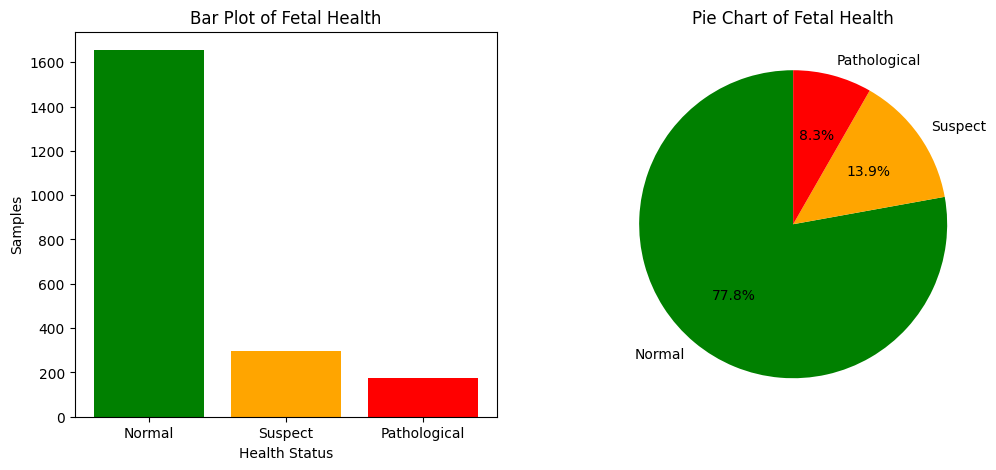

In [18]:

target_counts = df['fetal_health'].value_counts()
target_labels = {1: 'Normal', 2: 'Suspect', 3: 'Pathological'}
for value, count in target_counts.items():
    percent = count / len(df) * 100
    print(f"{target_labels[value]} (Class {value}): {count} samples ({percent:.2f}%)")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['green', 'orange', 'red']
axes[0].bar([target_labels[i] for i in target_counts.index], target_counts.values, color=colors)
axes[0].set_title('Bar Plot of Fetal Health')
axes[0].set_xlabel('Health Status')
axes[0].set_ylabel('Samples')
axes[1].pie(target_counts.values,
            labels=[target_labels[i] for i in target_counts.index],
            autopct='%1.1f%%',
            colors=colors,
            startangle=90)
axes[1].set_title('Pie Chart of Fetal Health')
plt.show()

2. How is the baseline fetal heart rate distributed?

Tells us about the basline fetal heart reate feature and shows us some outliners.

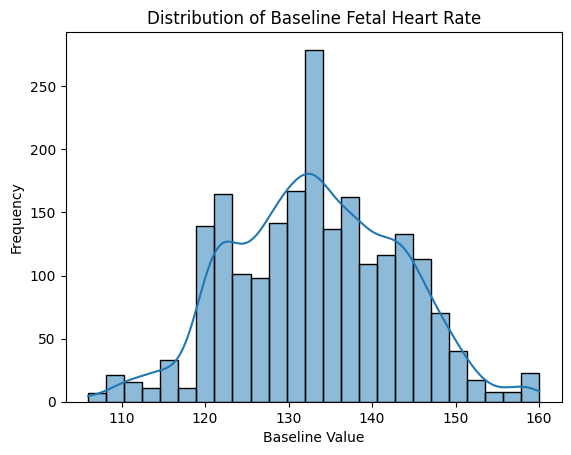

In [19]:
sns.histplot(df['baseline value'], kde=True)
plt.title("Distribution of Baseline Fetal Heart Rate")
plt.xlabel("Baseline Value")
plt.ylabel("Frequency")
plt.show()

3. How is Correlation Heatmap helps us to understand the all features?

This heatmap visualizes the correlation between all features in the dataset. Each cell represents the strength and direction of the relationship between two variables, where values close to +1 indicate a strong positive correlation, values close to -1 indicate a strong negative correlation, and values near 0 indicate little or no correlation. So, by analyzing the heatmap we can clearly spot the features which are strongly related to target variable "Fetal_health"

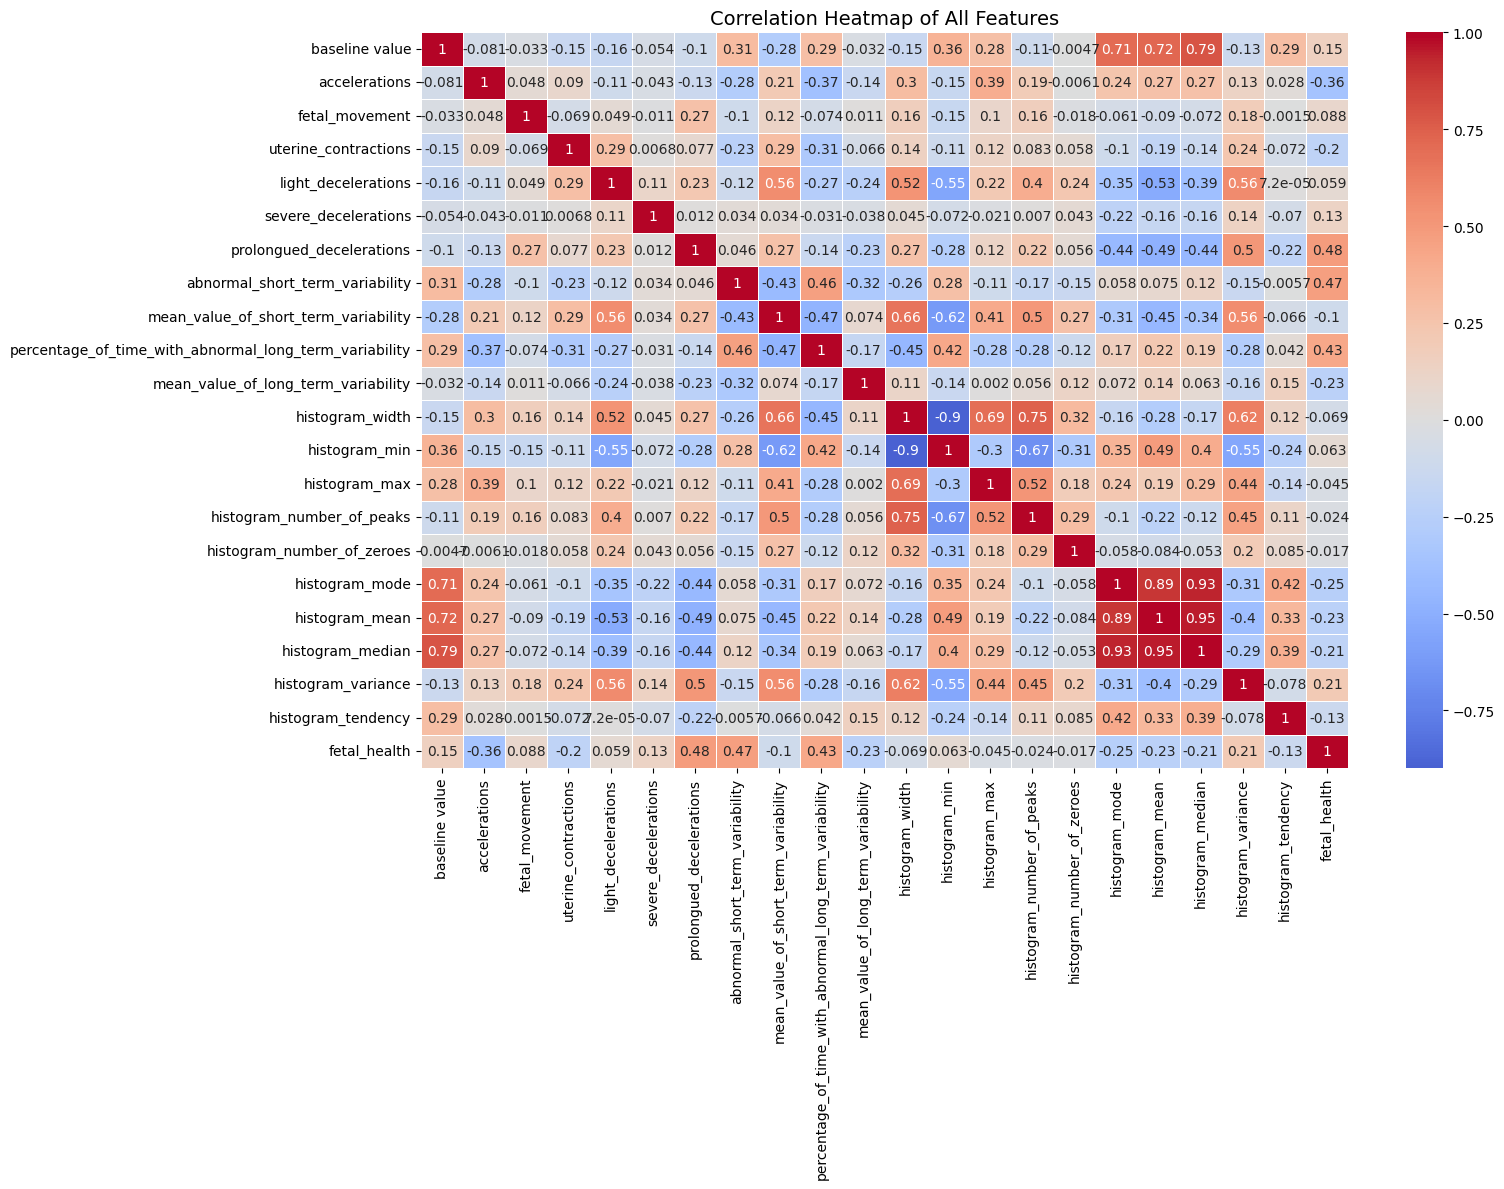

In [20]:

plt.figure(figsize=(16, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
           linewidths=0.5)
plt.title('Correlation Heatmap of All Features', fontsize=14)
plt.tight_layout()
plt.show()

4. What is the distribution of key features indiviudally?
By the hist plot we can clearly see the distribution among different features individually.

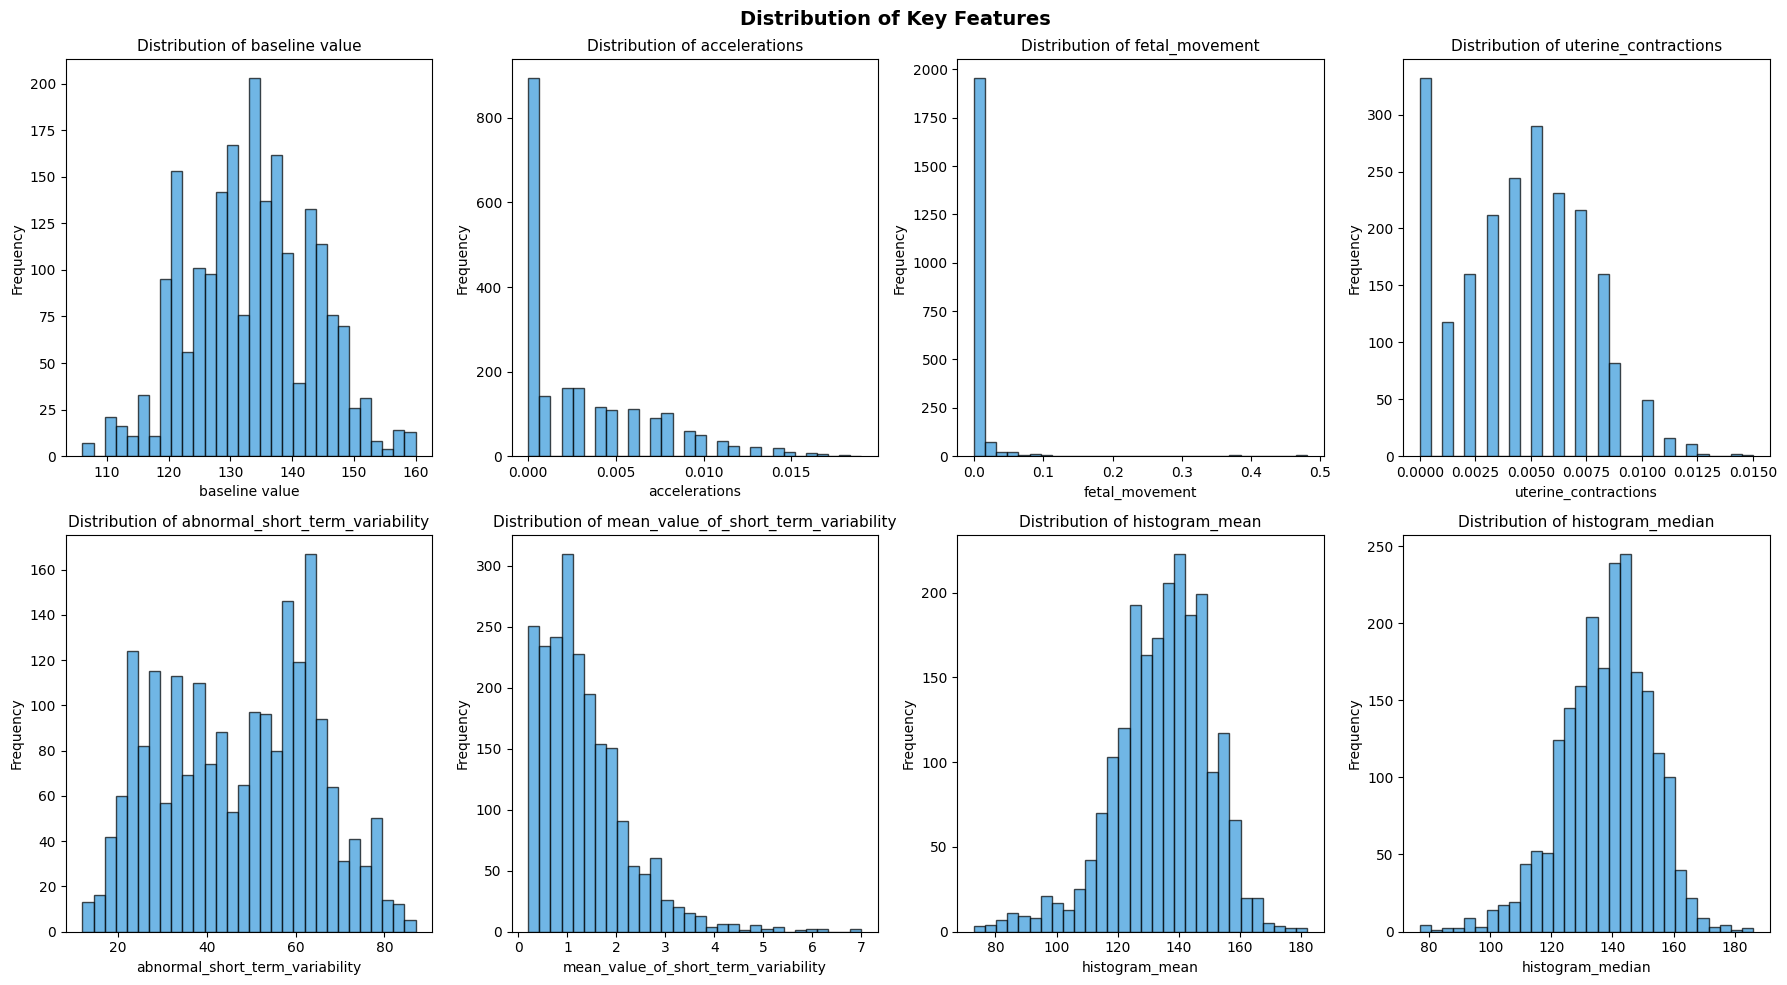

In [21]:
key_features = ['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions',
                'abnormal_short_term_variability', 'mean_value_of_short_term_variability',
                'histogram_mean', 'histogram_median']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    axes[i].hist(df[feature], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {feature}', fontsize=11)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

5. How do key features vary across different fetal health conditions?

This visualization helps in feature importance analysis and understanding class-wise differences, which is essential for building accurate machine learning models.

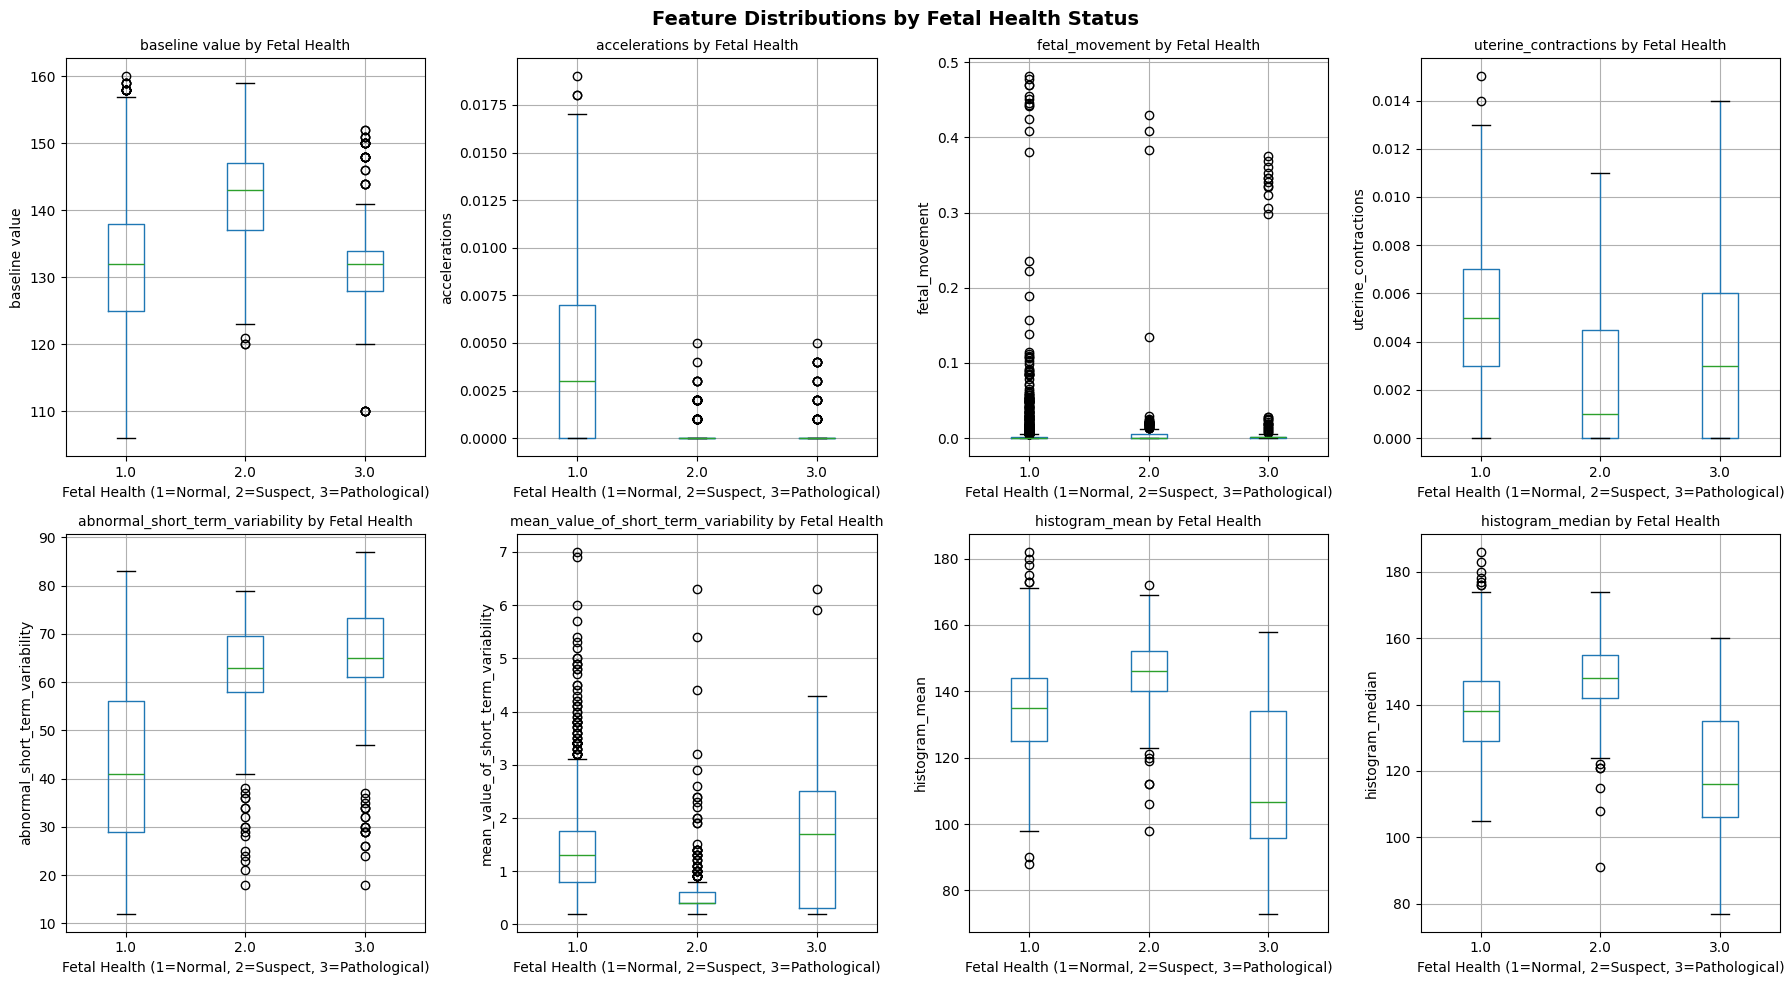

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    df.boxplot(column=feature, by='fetal_health', ax=axes[i])
    axes[i].set_title(f'{feature} by Fetal Health', fontsize=10)
    axes[i].set_xlabel('Fetal Health (1=Normal, 2=Suspect, 3=Pathological)')
    axes[i].set_ylabel(feature)

plt.suptitle('Feature Distributions by Fetal Health Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

6. What is the relationship between baseline heart rate and accelerations?

This scatterplot show us how much the baseline heart rate affects the acceleration which than affects the fetal health.


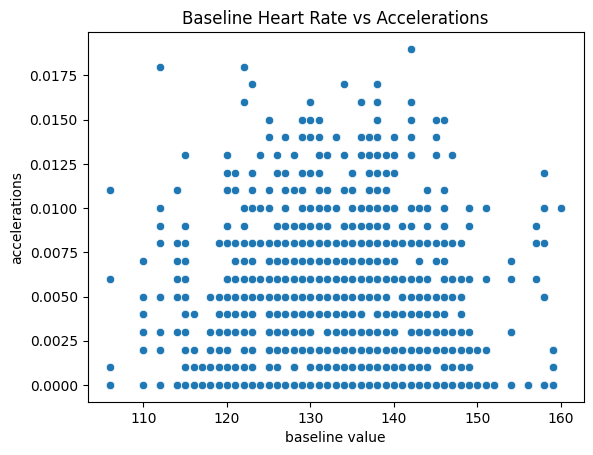

In [23]:
sns.scatterplot(x='baseline value', y='accelerations', data=df)
plt.title("Baseline Heart Rate vs Accelerations")
plt.show()

### Preprocessing Decisions Summary

| Decision | Reason |
|----------|--------|
| **No missing value handling needed** | Dataset has no missing values |
| **No categorical encoding needed** | All features are numerical |
| **Applied StandardScaler** | Ensures all features have mean=0 and std=1, important for SVM and Logistic Regression |
| **Used stratified split** | Maintains class proportions in train/test sets |
| **Kept all features** | All features are relevant medical measurements; no dimensionality reduction needed initially |

In [24]:
X = df.drop('fetal_health', axis=1)
y = df['fetal_health']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (2126, 21)
Target shape: (2126,)


###Train Test split


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Dataset Split:")
print("=" * 50)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"\nClass distribution in testing set:")
print(y_test.value_counts())

Dataset Split:
Training set: 1700 samples (80.0%)
Testing set: 426 samples (20.0%)

Class distribution in training set:
fetal_health
1.0    1323
2.0     236
3.0     141
Name: count, dtype: int64

Class distribution in testing set:
fetal_health
1.0    332
2.0     59
3.0     35
Name: count, dtype: int64


## ANN

In [27]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [55]:
# Adjust y_train and y_test to be 0-indexed for sparse_categorical_crossentropy
y_train = y_train - 1
y_test = y_test - 1

print("0-indexed Class distribution in training set:")
print(y_train.value_counts())
print("0-indexed Class distribution in testing set:")
print(y_test.value_counts())

0-indexed Class distribution in training set:
fetal_health
0.0    1323
1.0     236
2.0     141
Name: count, dtype: int64
0-indexed Class distribution in testing set:
fetal_health
0.0    332
1.0     59
2.0     35
Name: count, dtype: int64


In [28]:
X_train.shape

(1700, 21)

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU, PReLU, ELU, ReLU #Activation funciton.
from tensorflow.keras.layers import Dropout

In [30]:
classifier = Sequential()

In [32]:
classifier.add(Dense(units = 21, activation = 'relu'))

In [33]:
classifier.add(Dense(units = 15, activation = 'relu'))

In [34]:
classifier.add(Dense(units = 8, activation = 'relu'))

In [53]:
## Adding the output layer
classifier.add(Dense(units =3,activation = 'softmax'))

In [36]:
import tensorflow as tf
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)


In [54]:
classifier.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [56]:
model_history = classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100, callbacks=[early_stopping])

Epoch 1/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0729 - loss: 1.3286 - val_accuracy: 0.1032 - val_loss: 1.2034
Epoch 2/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0729 - loss: 1.1310 - val_accuracy: 0.1032 - val_loss: 1.0424
Epoch 3/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6098 - loss: 0.9826 - val_accuracy: 0.7616 - val_loss: 0.9258
Epoch 4/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7865 - loss: 0.8776 - val_accuracy: 0.7616 - val_loss: 0.8476
Epoch 5/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7865 - loss: 0.8055 - val_accuracy: 0.7616 - val_loss: 0.7960
Epoch 6/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7865 - loss: 0.7574 - val_accuracy: 0.7616 - val_loss: 0.7626
Epoch 7/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7865 - loss: 0.7253 - val_accuracy: 0.7616 - val_loss: 0.7423
Epoch 8/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7865 - loss: 0.7037 - val_accu

In [39]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [40]:
classifier.weights

[<Variable path=sequential/dense/kernel, shape=(21, 11), dtype=float32, value=[[  78.515526     78.77974      56.55309      57.28025      77.692245
     56.417366     78.82273     -39.280067     52.339245     78.513565
    -40.98226   ]
  [-100.95287    -101.029434   -104.38689    -104.26065    -101.13725
   -104.79177    -101.33573     -75.726456   -104.85295    -101.337776
    -75.5381    ]
  [   0.18424448  -83.88612      15.647618     14.525429      0.33351317
     14.860985    -83.95288      27.592293     15.434164      0.32863042
     27.27786   ]
  [ -89.61606     -88.817604    -69.52625     -68.691475    -89.390945
    -68.390305    -89.198        12.320386    -67.854294    -89.26941
     15.110644  ]
  [-100.23868    -100.14438     -15.926531    -15.710845    -99.58187
    -15.180142   -100.01786      52.60638      -4.333239   -100.117836
     52.915733  ]
  [-102.540245   -102.572784   -106.233246   -106.07511    -100.648254
   -106.132286   -102.727036     15.207433     17.4

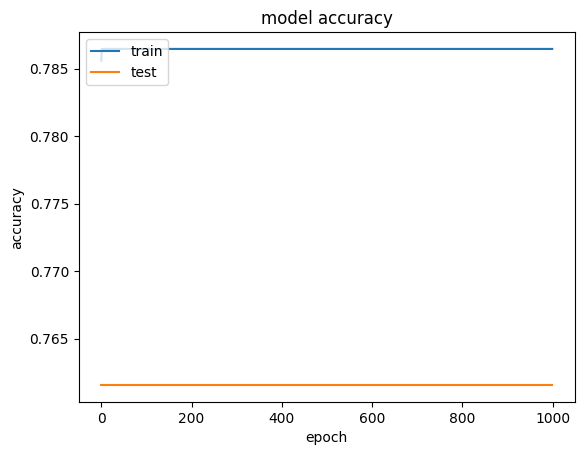

In [41]:
# summarize history for accuracy
plt.plot(model_history.history['accuracy' ])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [42]:
print(len(model_history.history['accuracy']))

1000


##Model Selection

We will use three algorithms:
- Logistic Regression
- Random Forest
- Support Vector Machine

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

## Phase 6 – Model Evaluation

In [ ]:
# Logistic Regression Evaluation
print('Logistic Regression Accuracy:', accuracy_score(y_test, pred_lr))
print(confusion_matrix(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

In [ ]:
# Random Forest Evaluation
print('Random Forest Accuracy:', accuracy_score(y_test, pred_rf))
print(confusion_matrix(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

In [ ]:
# SVM Evaluation
print('SVM Accuracy:', accuracy_score(y_test, pred_svm))
print(confusion_matrix(y_test, pred_svm))
print(classification_report(y_test, pred_svm))

## Model Comparison


In [ ]:
models = ['Logistic Regression','Random Forest','SVM']
accuracies = [
    accuracy_score(y_test, pred_lr),
    accuracy_score(y_test, pred_rf),
    accuracy_score(y_test, pred_svm)
]

plt.bar(models, accuracies)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()